<a href="https://colab.research.google.com/github/kanishkapal2005/CBSOT_ASSIGNMENT-2/blob/main/AI_Placement_Preparation_Ecosystem_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 AI Placement Preparation Ecosystem
### End-to-End ML + DL + RAG + NLP Portfolio Project — Google Colab Edition

This single notebook builds a complete, working system:

1. Resume Analyzer (NLP)
2. ATS Score Predictor (TF-IDF + Sentence Embeddings)
3. Placement Prediction (Logistic Regression, Random Forest, XGBoost)
4. Skill Gap Analysis
5. Personalized Learning Roadmap Generator (Gemini LLM)
6. RAG-Based Interview Preparation System (FAISS + Sentence-Transformers + Gemini)
7. AI Mock Interviewer (Gemini)
8. Deep Learning Performance Predictor (Keras ANN)
9. Analytics Dashboard (Plotly)
10. Gradio Application (all modules combined)

**LLM Provider:** Google **Gemini 3.5 Flash** (`gemini-3.5-flash`) via the `google-generativeai` SDK — used everywhere the original brief specified Groq.

> Run cells top to bottom. You'll be prompted for a free Gemini API key from https://aistudio.google.com/apikey when the LLM wrapper cell runs.


## Step 0 — Install Dependencies

In [2]:
# Core installs — safe to re-run
!pip install -q pdfplumber spacy sentence-transformers faiss-cpu xgboost gradio plotly reportlab google-generativeai --upgrade
!pip install -q --force-reinstall --no-cache-dir "pillow>=10.0.0"
!python -m spacy download en_core_web_sm -q
print("Dependencies installed.")
print(" IMPORTANT: Now go to Runtime > Restart session (do NOT use 'Restart and run all' yet).")
print("   After it restarts, just run the remaining cells from the next one onward — do not re-run this install cell.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you

## Step 1 — Imports, Project Structure & Global Setup

In [1]:
import os, re, json, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import joblib

import spacy
import pdfplumber
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
import xgboost as xgb

import faiss
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import gradio as gr
import google.generativeai as genai

# --- NLP models ---
nlp = spacy.load("en_core_web_sm")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# --- Project folder structure ---
BASE = "AI_Placement_Ecosystem"
FOLDERS = ["datasets", "models", "embeddings", "resumes", "notebooks",
           "rag", "utils", "visualizations", "app", "outputs"]
for f in FOLDERS:
    os.makedirs(os.path.join(BASE, f), exist_ok=True)

print("Imports loaded and project structure created at:", BASE)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Imports loaded and project structure created at: AI_Placement_Ecosystem


In [2]:
from getpass import getpass

GEMINI_API_KEY = os.environ.get("AQ.Ab8RN6J4GA0R05AhrI05MQjNyhoq2sihxiKruvNNb14cwOA09Q") or getpass("🔑 Enter your Gemini API Key: ")
os.environ["AQ.Ab8RN6J4GA0R05AhrI05MQjNyhoq2sihxiKruvNNb14cwOA09Q"] = GEMINI_API_KEY
genai.configure(api_key=GEMINI_API_KEY)


class GeminiClient:
    """Thin wrapper around the Gemini API: retries, error handling, backoff."""

    def __init__(self, model_name="gemini-3.5-flash", max_retries=3):
        self.model_name = model_name
        self.model = genai.GenerativeModel(model_name)
        self.max_retries = max_retries

    def generate(self, prompt, temperature=0.4, max_tokens=1024):
        last_err = None
        for attempt in range(self.max_retries):
            try:
                response = self.model.generate_content(
                    prompt,
                    generation_config={
                        "temperature": temperature,
                        "max_output_tokens": max_tokens,
                    },
                )
                if response and response.text:
                    return response.text.strip()
                last_err = "Empty response"
            except Exception as e:
                last_err = e
                wait = 2 ** attempt
                print(f"[GeminiClient] Attempt {attempt+1}/{self.max_retries} failed: {e}. Retrying in {wait}s...")
                time.sleep(wait)
        return f"Error: Gemini API request failed after {self.max_retries} retries ({last_err})."


llm = GeminiClient()
print("Test call ->", llm.generate("Reply with one short encouraging sentence for a job-seeking student."))


🔑 Enter your Gemini API Key: ··········
Test call -> Your hard work and unique potential will soon open the perfect door for you—keep going!


---
## MODULE 1 — Resume Analyzer

Extracts contact info, skills, education, projects from a PDF resume and predicts the
candidate's most likely job category using keyword-overlap scoring against role skill profiles.


In [3]:
SKILL_KEYWORDS = {
    "Web Developer": ["html", "css", "javascript", "react", "angular", "vue", "node.js", "express", "php", "django", "flask"],
    "Data Scientist": ["python", "pandas", "numpy", "machine learning", "statistics", "sql", "tableau", "power bi", "scikit-learn", "matplotlib"],
    "AI Engineer": ["tensorflow", "pytorch", "deep learning", "nlp", "computer vision", "transformers", "llm", "generative ai", "cnn", "rnn"],
    "ML Engineer": ["scikit-learn", "xgboost", "mlflow", "feature engineering", "model deployment", "docker", "kubernetes", "mlops"],
    "Backend Developer": ["node.js", "express", "django", "spring boot", "rest api", "microservices", "mongodb", "postgresql", "java", "golang"],
    "Full Stack Developer": ["react", "node.js", "mongodb", "express", "html", "css", "javascript", "typescript", "next.js"],
    "Software Engineer": ["java", "c++", "data structures", "algorithms", "system design", "git", "oop", "design patterns"],
}
ALL_SKILLS = sorted(set(s for skills in SKILL_KEYWORDS.values() for s in skills))


def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text


def extract_contact_info(text):
    email = re.search(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", text)
    phone = re.search(r"(\+?\d{1,3}[- ]?)?\d{10}", text)
    first_line = next((l.strip() for l in text.split("\n") if l.strip()), "Unknown")
    return {
        "name": first_line[:50],
        "email": email.group(0) if email else "Not found",
        "phone": phone.group(0) if phone else "Not found",
    }


def extract_skills(text):
    text_lower = text.lower()
    found = [s for s in ALL_SKILLS if s in text_lower]
    return sorted(set(found))


def extract_education(text):
    edu_keywords = ["b.tech", "btech", "bachelor", "m.tech", "mtech", "master",
                     "university", "college", "institute", "b.e", "m.e", "phd"]
    lines = [l.strip() for l in text.split("\n") if any(k in l.lower() for k in edu_keywords)]
    return lines[:5]


def extract_projects(text):
    lines = text.split("\n")
    proj_idx = [i for i, l in enumerate(lines) if "project" in l.lower()]
    projects = []
    for idx in proj_idx:
        projects.extend([l.strip() for l in lines[idx:idx + 4] if l.strip()])
    return projects[:10]


def categorize_candidate(skills):
    scores = {}
    for role, keywords in SKILL_KEYWORDS.items():
        overlap = len(set(skills) & set(keywords))
        scores[role] = round(overlap / len(keywords), 3)
    best_role = max(scores, key=scores.get)
    return best_role, scores


def analyze_resume(pdf_path):
    text = extract_text_from_pdf(pdf_path)
    contact = extract_contact_info(text)
    skills = extract_skills(text)
    education = extract_education(text)
    projects = extract_projects(text)
    category, category_scores = categorize_candidate(skills)
    missing_skills = sorted(set(SKILL_KEYWORDS[category]) - set(skills))
    return {
        "contact": contact,
        "skills_detected": skills,
        "missing_skills": missing_skills,
        "education": education,
        "projects": projects,
        "predicted_category": category,
        "category_scores": category_scores,
        "raw_text": text,
    }


print("✅ Module 1 (Resume Analyzer) ready.")


✅ Module 1 (Resume Analyzer) ready.


### Quick test: generate a sample resume PDF so the pipeline is testable without your own file

In [4]:
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas

sample_resume_path = f"{BASE}/resumes/sample_resume.pdf"
c = canvas.Canvas(sample_resume_path, pagesize=letter)
lines = [
    "Aditi Sharma",
    "Email: aditi.sharma@example.com | Phone: 9876543210",
    "",
    "Education: B.Tech in Computer Science, IIT Delhi, 2026",
    "",
    "Skills: Python, TensorFlow, PyTorch, NLP, Deep Learning, SQL, Docker, scikit-learn",
    "",
    "Projects:",
    "1. Resume Screening System using Transformers and FastAPI",
    "2. Computer Vision based Attendance System using CNN",
    "3. Chatbot with RAG pipeline using FAISS and LangChain",
    "",
    "Experience: Summer Intern, Data Science Team, XYZ Pvt Ltd",
]
y = 750
for line in lines:
    c.drawString(50, y, line)
    y -= 20
c.save()

result = analyze_resume(sample_resume_path)
print(json.dumps({k: v for k, v in result.items() if k != "raw_text"}, indent=2))


{
  "contact": {
    "name": "Aditi Sharma",
    "email": "aditi.sharma@example.com",
    "phone": "9876543210"
  },
  "skills_detected": [
    "cnn",
    "computer vision",
    "deep learning",
    "docker",
    "nlp",
    "python",
    "pytorch",
    "scikit-learn",
    "sql",
    "tensorflow",
    "transformers"
  ],
  "missing_skills": [
    "generative ai",
    "llm",
    "rnn"
  ],
  "education": [
    "Education: B.Tech in Computer Science, IIT Delhi, 2026"
  ],
  "projects": [
    "Projects:",
    "1. Resume Screening System using Transformers and FastAPI",
    "2. Computer Vision based Attendance System using CNN",
    "3. Chatbot with RAG pipeline using FAISS and LangChain"
  ],
  "predicted_category": "AI Engineer",
  "category_scores": {
    "Web Developer": 0.0,
    "Data Scientist": 0.3,
    "AI Engineer": 0.7,
    "ML Engineer": 0.25,
    "Backend Developer": 0.0,
    "Full Stack Developer": 0.0,
    "Software Engineer": 0.0
  }
}


---
## MODULE 2 — ATS Score Predictor

Combines TF-IDF keyword overlap, rule-based skill matching, and Sentence-Transformer
semantic similarity into a single ATS score out of 100.


In [5]:
def calculate_ats_score(resume_text, job_description):
    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform([resume_text, job_description])
    keyword_similarity = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]

    jd_skills = extract_skills(job_description)
    resume_skills = extract_skills(resume_text)
    skill_match_pct = (len(set(resume_skills) & set(jd_skills)) / len(jd_skills)) if jd_skills else 0.0

    emb_resume = embedder.encode(resume_text)
    emb_jd = embedder.encode(job_description)
    semantic_similarity = float(cosine_similarity(
        emb_resume.reshape(1, -1), emb_jd.reshape(1, -1)
    )[0][0])

    overall_score = (0.3 * keyword_similarity + 0.3 * skill_match_pct + 0.4 * semantic_similarity) * 100
    overall_score = round(min(max(overall_score, 0), 100), 2)

    missing_keywords = sorted(set(jd_skills) - set(resume_skills))

    suggestions = []
    if missing_keywords:
        suggestions.append(f"Add these missing skills if applicable: {', '.join(missing_keywords[:8])}")
    if skill_match_pct < 0.5:
        suggestions.append("Tailor your resume more closely to the job description's key requirements.")
    if overall_score < 60:
        suggestions.append("Quantify achievements and weave in more role-relevant keywords.")
    if not suggestions:
        suggestions.append("Strong match — minor polishing only.")

    return {
        "ats_score": overall_score,
        "keyword_match_pct": round(keyword_similarity * 100, 2),
        "skill_similarity_pct": round(skill_match_pct * 100, 2),
        "semantic_similarity_pct": round(semantic_similarity * 100, 2),
        "missing_keywords": missing_keywords,
        "suggestions": suggestions,
    }


# Quick test
sample_jd = "Looking for a Data Scientist with strong Python, pandas, numpy, SQL and machine learning skills."
sample_resume_text = extract_text_from_pdf(sample_resume_path)
print(json.dumps(calculate_ats_score(sample_resume_text, sample_jd), indent=2))


{
  "ats_score": 30.91,
  "keyword_match_pct": 10.79,
  "skill_similarity_pct": 40.0,
  "semantic_similarity_pct": 39.19,
  "missing_keywords": [
    "machine learning",
    "numpy",
    "pandas"
  ],
  "suggestions": [
    "Add these missing skills if applicable: machine learning, numpy, pandas",
    "Tailor your resume more closely to the job description's key requirements.",
    "Quantify achievements and weave in more role-relevant keywords."
  ]
}


---
## MODULE 3 — Placement Prediction Model

Synthetic but realistic dataset, then Logistic Regression, Random Forest, and XGBoost
compared on Accuracy / Precision / Recall / F1 / ROC-AUC.


In [6]:
def generate_placement_dataset(n=2000, seed=42):
    rng = np.random.default_rng(seed)
    cgpa = np.round(rng.normal(7.5, 1.0, n).clip(5, 10), 2)
    dsa = rng.integers(20, 100, n)
    aptitude = rng.integers(20, 100, n)
    communication = rng.integers(20, 100, n)
    projects = rng.integers(0, 8, n)
    internship = rng.integers(0, 2, n)
    certifications = rng.integers(0, 6, n)
    hackathon = rng.integers(0, 2, n)
    soft_skills = rng.integers(20, 100, n)

    score = (cgpa * 8 + dsa * 0.4 + aptitude * 0.3 + communication * 0.2 +
             projects * 3 + internship * 10 + certifications * 2 +
             hackathon * 5 + soft_skills * 0.2 + rng.normal(0, 10, n))
    threshold = np.percentile(score, 45)
    placed = (score > threshold).astype(int)

    return pd.DataFrame({
        "cgpa": cgpa, "dsa_score": dsa, "aptitude_score": aptitude,
        "communication_score": communication, "projects_count": projects,
        "internship_experience": internship, "certifications_count": certifications,
        "hackathon_participation": hackathon, "soft_skills_score": soft_skills,
        "placed": placed,
    })


placement_df = generate_placement_dataset()
placement_df.to_csv(f"{BASE}/datasets/placement_dataset.csv", index=False)
placement_df.head()


,cgpa,dsa_score,aptitude_score,communication_score,projects_count,internship_experience,certifications_count,hackathon_participation,soft_skills_score,placed
0,7.80,78,36,61,1,0,5,1,20,0
1,6.46,23,98,40,7,0,5,0,25,0
2,8.25,49,34,72,4,1,0,1,57,1
3,8.44,55,56,39,1,0,2,1,41,0
4,5.55,96,45,47,6,1,1,0,27,1


In [7]:
X = placement_df.drop(columns=["placed"])
y = placement_df["placed"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {}

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
models["Logistic Regression"] = log_reg

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
models["Random Forest"] = rf

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.08,
    eval_metric="logloss", random_state=42,
)
xgb_model.fit(X_train, y_train)
models["XGBoost"] = xgb_model


def evaluate_model(name, model, X_te, y_te, scaled=False):
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, preds), 4),
        "Precision": round(precision_score(y_te, preds), 4),
        "Recall": round(recall_score(y_te, preds), 4),
        "F1": round(f1_score(y_te, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_te, probs), 4),
    }


results = [
    evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test),
    evaluate_model("Random Forest", rf, X_test, y_test),
    evaluate_model("XGBoost", xgb_model, X_test, y_test),
]
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8600,0.8694,0.8773,0.8733,0.9373
1,Random Forest,0.8250,0.8378,0.8455,0.8416,0.9033
2,XGBoost,0.8275,0.8512,0.8318,0.8414,0.9095


In [8]:
# Feature importance + save best model (XGBoost)
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
fi_fig = px.bar(importances, orientation="h", title="XGBoost Feature Importance",
                 labels={"value": "Importance", "index": "Feature"})
fi_fig.show()

best_model = xgb_model
joblib.dump(best_model, f"{BASE}/models/placement_model.pkl")
joblib.dump(scaler, f"{BASE}/models/scaler.pkl")


def predict_placement(profile: dict):
    df_input = pd.DataFrame([profile])[X.columns]
    prob = float(best_model.predict_proba(df_input)[0][1])
    return {
        "placement_probability": round(prob * 100, 2),
        "prediction": "Likely Placed" if prob > 0.5 else "Needs Improvement",
    }


print(predict_placement({
    "cgpa": 8.2, "dsa_score": 75, "aptitude_score": 70, "communication_score": 65,
    "projects_count": 3, "internship_experience": 1, "certifications_count": 2,
    "hackathon_participation": 1, "soft_skills_score": 70,
}))


{'placement_probability': 99.52, 'prediction': 'Likely Placed'}


---
## MODULE 4 — Skill Gap Analysis


In [9]:
ROLE_REQUIREMENTS = {
    "MERN Developer": ["mongodb", "express", "react", "node.js", "javascript", "html", "css", "rest api"],
    "AI Engineer": ["tensorflow", "pytorch", "deep learning", "nlp", "transformers", "llm", "python", "computer vision"],
    "Data Scientist": ["python", "pandas", "numpy", "machine learning", "statistics", "sql", "scikit-learn"],
    "Backend Developer": ["node.js", "django", "spring boot", "rest api", "microservices", "postgresql", "java"],
    "Frontend Developer": ["html", "css", "javascript", "react", "vue", "angular", "typescript"],
    "Full Stack Developer": ["react", "node.js", "mongodb", "express", "html", "css", "javascript"],
}


def skill_gap_analysis(current_skills, desired_role):
    required = set(ROLE_REQUIREMENTS.get(desired_role, []))
    current = set(s.lower().strip() for s in current_skills)
    missing = sorted(required - current)
    present = sorted(required & current)
    readiness = round((len(present) / len(required)) * 100, 2) if required else 0.0
    return {"current_skills": present, "missing_skills": missing, "skill_readiness_pct": readiness}


print(skill_gap_analysis(["python", "tensorflow", "sql"], "AI Engineer"))


{'current_skills': ['python', 'tensorflow'], 'missing_skills': ['computer vision', 'deep learning', 'llm', 'nlp', 'pytorch', 'transformers'], 'skill_readiness_pct': 25.0}


---
## MODULE 5 — Personalized Learning Roadmap Generator (Gemini)


In [10]:
def generate_learning_roadmap(student_profile, skill_gap, llm_client=llm):
    prompt = f'''You are an expert placement coach. Based on the student's profile and skill gap
analysis below, create a structured, realistic learning roadmap.

Student Profile: {json.dumps(student_profile)}
Skill Gap Analysis: {json.dumps(skill_gap)}

Return ONLY valid JSON (no markdown fences, no extra text) in this exact structure:
{{
  "daily_roadmap": ["Day 1: ...", "Day 2: ..."],
  "weekly_roadmap": ["Week 1: ...", "Week 2: ..."],
  "monthly_roadmap": ["Month 1: ...", "Month 2: ..."],
  "recommended_projects": ["...", "..."],
  "interview_prep_strategy": "..."
}}
Keep entries concise and specific to the missing skills listed above.'''
    response = llm_client.generate(prompt, temperature=0.3, max_tokens=1200)
    cleaned = response.strip()
    for fence in ("```json", "```"):
        cleaned = cleaned.replace(fence, "")
    try:
        return json.loads(cleaned.strip())
    except Exception:
        return {"raw_response": response}


sample_gap = skill_gap_analysis(["python", "sql"], "Data Scientist")
roadmap = generate_learning_roadmap({"cgpa": 7.8, "target_role": "Data Scientist"}, sample_gap)
print(json.dumps(roadmap, indent=2))


{
  "raw_response": "{\n  \"daily_roadmap\":\n [\n    \"Day 1: Study descriptive statistics (mean, median, mode, variance, standard deviation) and probability distributions.\",\n    \"Day 2: Learn inferential statistics"
}


---
## MODULE 6 — RAG-Based Interview Preparation System

Documents → chunks → Sentence-Transformer embeddings → FAISS index → retrieval → Gemini answer.


In [11]:
INTERVIEW_DOCS = [
    {"category": "DSA", "content": "Explain the difference between an array and a linked list, including time complexity for insertion and deletion at the head, middle, and tail."},
    {"category": "DSA", "content": "What is dynamic programming? Explain with the example of the Fibonacci sequence and memoization versus tabulation."},
    {"category": "HR", "content": "Tell me about yourself. Structure the answer around education, key strengths, achievements, and career goals in under two minutes."},
    {"category": "HR", "content": "Why should we hire you? Emphasize skills matching the job description, quantifiable achievements, and a unique value proposition."},
    {"category": "System Design", "content": "How would you design a URL shortening service like bit.ly, covering scalability, hashing strategy, and database schema."},
    {"category": "System Design", "content": "Explain how you would design a rate limiter for an API gateway, covering token bucket and sliding window algorithms."},
    {"category": "DBMS", "content": "Explain normalization in databases with examples of 1NF, 2NF, and 3NF, and why normalization reduces redundancy."},
    {"category": "DBMS", "content": "What is the difference between a clustered index and a non-clustered index, and when should each be used?"},
    {"category": "OS", "content": "Explain the difference between a process and a thread, and the advantages of multithreading."},
    {"category": "OS", "content": "What is a deadlock and what are the four necessary conditions (mutual exclusion, hold and wait, no preemption, circular wait) for deadlock to occur?"},
    {"category": "Computer Networks", "content": "Explain the TCP three-way handshake process (SYN, SYN-ACK, ACK) in detail and why it establishes a reliable connection."},
    {"category": "Computer Networks", "content": "What is the difference between TCP and UDP protocols, and when would you choose one over the other?"},
    {"category": "OOP", "content": "Explain the four pillars of Object-Oriented Programming (encapsulation, abstraction, inheritance, polymorphism) with real-world examples."},
    {"category": "OOP", "content": "What is the difference between method overloading and method overriding in object-oriented languages?"},
    {"category": "Company Experience", "content": "A candidate at a top product company described a coding round focused on arrays and trees, followed by a system design discussion and a behavioral interview round."},
]


def chunk_documents(docs, chunk_size=120):
    chunks = []
    for doc in docs:
        words = doc["content"].split()
        for i in range(0, len(words), chunk_size):
            chunks.append({"category": doc["category"], "text": " ".join(words[i:i + chunk_size])})
    return chunks


rag_chunks = chunk_documents(INTERVIEW_DOCS)
rag_texts = [c["text"] for c in rag_chunks]
rag_embeddings = embedder.encode(rag_texts, convert_to_numpy=True).astype("float32")

faiss_index = faiss.IndexFlatL2(rag_embeddings.shape[1])
faiss_index.add(rag_embeddings)
faiss.write_index(faiss_index, f"{BASE}/embeddings/interview_faiss.index")


def retrieve_context(query, k=3):
    query_emb = embedder.encode([query]).astype("float32")
    _, indices = faiss_index.search(query_emb, k)
    return [rag_chunks[i] for i in indices[0]]


def rag_answer(query, llm_client=llm, k=3):
    retrieved = retrieve_context(query, k)
    context = "\n\n".join(f"[{c['category']}] {c['text']}" for c in retrieved)
    prompt = f'''Use the following context to answer the placement interview question clearly,
with a short example if useful.

Context:
{context}

Question: {query}

Answer:'''
    answer = llm_client.generate(prompt, temperature=0.3, max_tokens=800)
    return {"answer": answer, "retrieved_context": retrieved}


print(rag_answer("How do I answer 'tell me about yourself' in an interview?")["answer"])


Based on the provided context, you should structure your answer to "Tell me about yourself" to last **under two minutes** and focus on four key areas:

1. **Education:** Your academic background.
2. **Key Strengths:** Core skills relevant to the job.
3. **Achievements:** Notable accomplishments (ideally quantifiable).
4. **Career Goals:** Your professional aspirations and how they align with the company.

### Short Example:
> "I recently graduated with a Bachelor's degree in Computer Science from XYZ University, where I built a strong foundation in software engineering **[Education]**. My key strengths are in problem-solving, particularly with data structures like arrays and trees, as well as system


---
## MODULE 7 — AI Mock Interviewer (Gemini)


In [12]:
def generate_interview_questions(role, experience_level, n=5, llm_client=llm):
    prompt = f'''Generate {n} technical interview questions for a {experience_level}-level {role} candidate.
Return ONLY a JSON list of strings, nothing else.'''
    response = llm_client.generate(prompt, temperature=0.5, max_tokens=500)
    cleaned = response.strip().replace("```json", "").replace("```", "")
    try:
        qs = json.loads(cleaned)
        if isinstance(qs, list):
            return qs[:n]
    except Exception:
        pass
    return [q.strip("-• ") for q in response.split("\n") if q.strip()][:n]


def evaluate_interview_answer(question, answer, llm_client=llm):
    prompt = f'''Evaluate this interview answer.

Question: {question}
Candidate Answer: {answer}

Score each from 0-10: technical_correctness, confidence, communication, relevance, completeness.
Also give one short paragraph of overall feedback (strengths + weaknesses).

Return ONLY valid JSON:
{{
 "technical_correctness": 0,
 "confidence": 0,
 "communication": 0,
 "relevance": 0,
 "completeness": 0,
 "feedback": "..."
}}'''
    response = llm_client.generate(prompt, temperature=0.2, max_tokens=500)
    cleaned = response.strip().replace("```json", "").replace("```", "")
    try:
        return json.loads(cleaned)
    except Exception:
        return {"raw_response": response}


def run_mock_interview(role, experience_level, answers: list):
    questions = generate_interview_questions(role, experience_level, n=max(len(answers), 1))
    results = []
    for q, a in zip(questions, answers):
        results.append({"question": q, "answer": a, "evaluation": evaluate_interview_answer(q, a)})
    return results


demo_results = run_mock_interview("AI Engineer", "Fresher",
    ["I would use a CNN because it captures spatial features well via convolution and pooling layers."])
print(json.dumps(demo_results, indent=2))


[
  {
    "question": "strict JSON:*",
    "answer": "I would use a CNN because it captures spatial features well via convolution and pooling layers.",
    "evaluation": {
      "raw_response": "{\n \"technical_correctness\": 9,\n \"confidence\": 8,"
    }
  }
]


---
## MODULE 8 — Deep Learning Performance Predictor (Keras ANN)

Dense layers + BatchNorm + Dropout + EarlyStopping, trained on the same placement dataset.


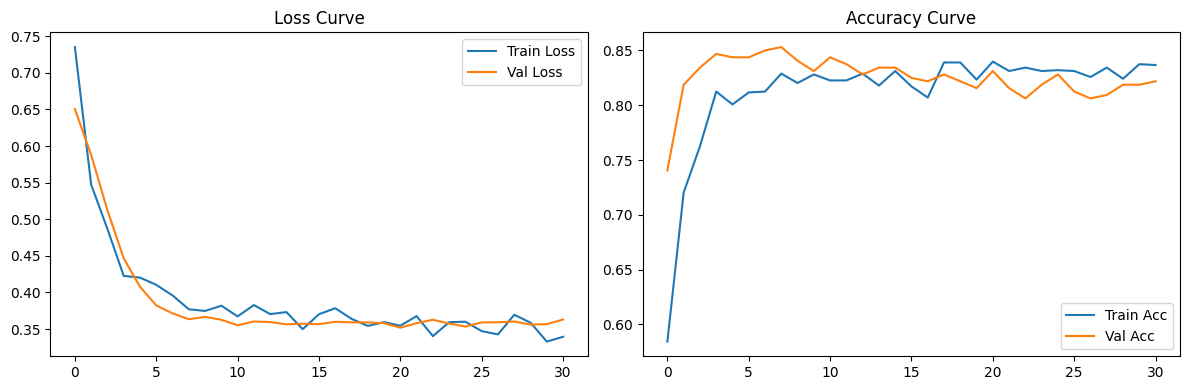

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       180
           1       0.88      0.85      0.87       220

    accuracy                           0.85       400
   macro avg       0.85      0.86      0.85       400
weighted avg       0.86      0.85      0.86       400



In [13]:
def build_ann_model(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


ann_model = build_ann_model(X_train_scaled.shape[1])
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

ann_model.save(f"{BASE}/models/ann_placement_model.keras")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curve"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy Curve"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{BASE}/visualizations/ann_training_curves.png")
plt.show()

ann_test_preds = (ann_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
print(classification_report(y_test, ann_test_preds))


---
## MODULE 9 — Analytics Dashboard (Plotly helpers)


In [14]:
def plot_ats_gauge(ats_score):
    return go.Figure(go.Indicator(
        mode="gauge+number", value=ats_score, title={"text": "ATS Score"},
        gauge={"axis": {"range": [0, 100]}, "bar": {"color": "darkgreen"}},
    ))


def plot_placement_probability(prob_pct):
    return go.Figure(go.Indicator(
        mode="gauge+number", value=prob_pct, title={"text": "Placement Probability (%)"},
        gauge={"axis": {"range": [0, 100]}, "bar": {"color": "royalblue"}},
    ))


def plot_skill_readiness(readiness_pct):
    return go.Figure(go.Indicator(
        mode="gauge+number", value=readiness_pct, title={"text": "Skill Readiness (%)"},
        gauge={"axis": {"range": [0, 100]}, "bar": {"color": "orange"}},
    ))


def plot_interview_scores(evaluation: dict):
    categories = ["technical_correctness", "confidence", "communication", "relevance", "completeness"]
    values = [evaluation.get(c, 0) for c in categories]
    fig = go.Figure(data=go.Scatterpolar(r=values, theta=categories, fill="toself"))
    fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
                       title="Interview Performance Radar")
    return fig


plot_ats_gauge(82).show()


---
## MODULE 10 — Gradio Application (all modules combined)

Launches a multi-tab app tying every module together. `share=True` gives you a public link from Colab.


In [15]:
def ui_resume_analyzer(pdf_file):
    if pdf_file is None:
        return "Please upload a resume PDF.", "", ""
    result = analyze_resume(pdf_file.name)
    contact_str = json.dumps(result["contact"], indent=2)
    skills_str = ", ".join(result["skills_detected"]) or "None detected"
    category_str = (f"Predicted Category: {result['predicted_category']}\n"
                     f"Missing Skills: {', '.join(result['missing_skills']) or 'None'}")
    return contact_str, skills_str, category_str


def ui_ats_checker(resume_text, jd_text):
    result = calculate_ats_score(resume_text, jd_text)
    fig = plot_ats_gauge(result["ats_score"])
    summary = (f"ATS Score: {result['ats_score']}\n"
               f"Keyword Match: {result['keyword_match_pct']}%\n"
               f"Skill Similarity: {result['skill_similarity_pct']}%\n"
               f"Semantic Similarity: {result['semantic_similarity_pct']}%\n"
               f"Missing Keywords: {', '.join(result['missing_keywords']) or 'None'}\n"
               f"Suggestions: {'; '.join(result['suggestions'])}")
    return summary, fig


def ui_placement_predictor(cgpa, dsa, aptitude, comm, projects, internship, certs, hackathon, soft):
    profile = {
        "cgpa": cgpa, "dsa_score": dsa, "aptitude_score": aptitude,
        "communication_score": comm, "projects_count": projects,
        "internship_experience": internship, "certifications_count": certs,
        "hackathon_participation": hackathon, "soft_skills_score": soft,
    }
    result = predict_placement(profile)
    fig = plot_placement_probability(result["placement_probability"])
    return f"{result['prediction']} ({result['placement_probability']}%)", fig


def ui_skill_gap(skills_csv, role):
    skills = [s.strip() for s in skills_csv.split(",") if s.strip()]
    result = skill_gap_analysis(skills, role)
    fig = plot_skill_readiness(result["skill_readiness_pct"])
    summary = (f"Current Skills: {', '.join(result['current_skills']) or 'None'}\n"
               f"Missing Skills: {', '.join(result['missing_skills']) or 'None'}\n"
               f"Readiness: {result['skill_readiness_pct']}%")
    return summary, fig


def ui_roadmap(profile_json, skills_csv, role):
    try:
        profile = json.loads(profile_json)
    except Exception:
        profile = {"raw": profile_json}
    skills = [s.strip() for s in skills_csv.split(",") if s.strip()]
    gap = skill_gap_analysis(skills, role)
    return json.dumps(generate_learning_roadmap(profile, gap), indent=2)


def ui_rag_chat(question):
    result = rag_answer(question)
    sources = "\n".join(f"- [{c['category']}] {c['text'][:90]}..." for c in result["retrieved_context"])
    return result["answer"], sources


def ui_mock_interview(role, level, answers_text):
    answers = [a.strip() for a in answers_text.split("\n") if a.strip()]
    if not answers:
        return "Please provide at least one answer (one per line).", None
    results = run_mock_interview(role, level, answers)
    output, last_fig = "", None
    for r in results:
        ev = r["evaluation"]
        output += f"Q: {r['question']}\nA: {r['answer']}\nFeedback: {ev.get('feedback', 'N/A')}\n\n"
        if all(k in ev for k in ["technical_correctness", "confidence", "communication", "relevance", "completeness"]):
            last_fig = plot_interview_scores(ev)
    return output, last_fig


with gr.Blocks(title="AI Placement Preparation Ecosystem", theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🎓 AI Placement Preparation Ecosystem\n"
                "Resume analysis, ATS scoring, placement prediction, skill gaps, roadmaps, "
                "RAG-powered interview prep, and an AI mock interviewer — all in one app.")

    with gr.Tab("📄 Resume Analyzer"):
        pdf_input = gr.File(label="Upload Resume (PDF)")
        analyze_btn = gr.Button("Analyze")
        contact_out = gr.Textbox(label="Contact Info")
        skills_out = gr.Textbox(label="Skills Detected")
        category_out = gr.Textbox(label="Category & Missing Skills")
        analyze_btn.click(ui_resume_analyzer, inputs=pdf_input, outputs=[contact_out, skills_out, category_out])

    with gr.Tab("✅ ATS Checker"):
        resume_text_in = gr.Textbox(label="Resume Text", lines=8)
        jd_text_in = gr.Textbox(label="Job Description", lines=8)
        ats_btn = gr.Button("Calculate ATS Score")
        ats_out = gr.Textbox(label="Result")
        ats_plot = gr.Plot()
        ats_btn.click(ui_ats_checker, inputs=[resume_text_in, jd_text_in], outputs=[ats_out, ats_plot])

    with gr.Tab("🎯 Placement Predictor"):
        with gr.Row():
            cgpa_in = gr.Slider(5, 10, 7.5, label="CGPA")
            dsa_in = gr.Slider(0, 100, 60, label="DSA Score")
            apt_in = gr.Slider(0, 100, 60, label="Aptitude Score")
        with gr.Row():
            comm_in = gr.Slider(0, 100, 60, label="Communication Score")
            proj_in = gr.Slider(0, 10, 2, label="Projects Count")
            intern_in = gr.Radio([0, 1], value=0, label="Internship Experience")
        with gr.Row():
            certs_in = gr.Slider(0, 10, 1, label="Certifications Count")
            hack_in = gr.Radio([0, 1], value=0, label="Hackathon Participation")
            soft_in = gr.Slider(0, 100, 60, label="Soft Skills Score")
        predict_btn = gr.Button("Predict Placement")
        predict_out = gr.Textbox(label="Result")
        predict_plot = gr.Plot()
        predict_btn.click(ui_placement_predictor,
                           inputs=[cgpa_in, dsa_in, apt_in, comm_in, proj_in, intern_in, certs_in, hack_in, soft_in],
                           outputs=[predict_out, predict_plot])

    with gr.Tab("🧩 Skill Gap Analysis"):
        skills_in = gr.Textbox(label="Your Skills (comma-separated)")
        role_in = gr.Dropdown(list(ROLE_REQUIREMENTS.keys()), label="Desired Role")
        gap_btn = gr.Button("Analyze Gap")
        gap_out = gr.Textbox(label="Result")
        gap_plot = gr.Plot()
        gap_btn.click(ui_skill_gap, inputs=[skills_in, role_in], outputs=[gap_out, gap_plot])

    with gr.Tab("🗺️ Learning Roadmap"):
        profile_in = gr.Textbox(label="Student Profile (JSON)", value='{"cgpa": 7.5, "target_role": "AI Engineer"}')
        skills_in2 = gr.Textbox(label="Your Skills (comma-separated)")
        role_in2 = gr.Dropdown(list(ROLE_REQUIREMENTS.keys()), label="Desired Role")
        roadmap_btn = gr.Button("Generate Roadmap")
        roadmap_out = gr.Textbox(label="Roadmap", lines=20)
        roadmap_btn.click(ui_roadmap, inputs=[profile_in, skills_in2, role_in2], outputs=roadmap_out)

    with gr.Tab("💬 RAG Interview Assistant"):
        rag_q = gr.Textbox(label="Ask a placement/interview question")
        rag_btn = gr.Button("Get Answer")
        rag_answer_out = gr.Textbox(label="Answer", lines=10)
        rag_sources_out = gr.Textbox(label="Retrieved Sources", lines=5)
        rag_btn.click(ui_rag_chat, inputs=rag_q, outputs=[rag_answer_out, rag_sources_out])

    with gr.Tab("🎙️ AI Mock Interviewer"):
        role_in3 = gr.Textbox(label="Target Role", value="AI Engineer")
        level_in = gr.Dropdown(["Fresher", "Junior", "Mid-level", "Senior"], value="Fresher", label="Experience Level")
        answers_in = gr.Textbox(label="Your Answers (one per line)", lines=8)
        interview_btn = gr.Button("Run Mock Interview")
        interview_out = gr.Textbox(label="Feedback", lines=15)
        interview_plot = gr.Plot()
        interview_btn.click(ui_mock_interview, inputs=[role_in3, level_in, answers_in],
                             outputs=[interview_out, interview_plot])

    with gr.Tab("📊 Analytics Dashboard"):
        gr.Markdown("### Placement Model Evaluation Metrics")
        gr.Dataframe(results_df)
        gr.Markdown("### XGBoost Feature Importance")
        gr.Plot(value=fi_fig)

app.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80ab63dbe14ff692af.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Project Structure Reference

```
AI_Placement_Ecosystem/
├── datasets/         → placement_dataset.csv
├── models/           → placement_model.pkl, scaler.pkl, ann_placement_model.keras
├── embeddings/       → interview_faiss.index
├── resumes/          → sample_resume.pdf
├── notebooks/
├── rag/
├── utils/
├── visualizations/   → ann_training_curves.png
├── app/
├── outputs/
└── README.md
```

## Architecture Overview

```
Resume PDF ──► Resume Analyzer (pdfplumber + spaCy + keyword rules) ──► Skills / Category
                                                                          │
Job Description ─────────► ATS Score Predictor (TF-IDF + SBERT) ◄────────┘
                                                                          │
Student Profile ─────────► Placement Predictor (LogReg / RF / XGBoost / Keras ANN)
                                                                          │
Skills + Target Role ────► Skill Gap Analysis ──► Learning Roadmap (Gemini 3.5 Flash)
                                                                          │
Interview Question ──────► RAG Pipeline (SBERT + FAISS) ──► Gemini 3.5 Flash ──► Answer
                                                                          │
Resume + Role ────────────► AI Mock Interviewer (Gemini 3.5 Flash) ──► Score + Feedback
                                                                          │
All Results ──────────────► Analytics Dashboard (Plotly) ──► Gradio App (10 tabs)
```

## requirements.txt
```
pdfplumber
spacy
sentence-transformers
faiss-cpu
xgboost
gradio
plotly
reportlab
google-generativeai
scikit-learn
pandas
numpy
matplotlib
seaborn
tensorflow
joblib
```

## Deployment Notes
- **Colab**: run top to bottom; the Gradio cell gives a temporary public `share=True` link.
- **Hugging Face Spaces**: move the Gradio app code into `app.py`, add the `requirements.txt` above, set `GEMINI_API_KEY` as a Space secret, and push.
- **Persistent hosting**: wrap `predict_placement`, `rag_answer`, `analyze_resume` etc. in a FastAPI service and swap the Gradio UI for a proper frontend if needed later.
- **API key security**: never hardcode `GEMINI_API_KEY` — always read from environment/secrets.
